In [ ]:
#DRIVE CONNECTION
from google.colab import files

uploaded = files.upload()

Saving ddxplus.zip to ddxplus.zip


In [ ]:
import zipfile
import os

zip_path = "/content/ddxplus.zip"
extract_path = "/content/ddxplus"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extracted files:")
print(os.listdir(extract_path))

Extracted files:
['train.csv', 'release_conditions.json', '__MACOSX', 'README.md', 'validate.csv', 'release_evidences.json', 'test.csv']


In [ ]:
# INSTALLS
!pip install scikit-learn

In [ ]:
# IMPORTS
import pandas as pd
import ast
import joblib

from sklearn.preprocessing import (
    MultiLabelBinarizer,
    LabelEncoder
)

from scipy.sparse import hstack, csr_matrix

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    confusion_matrix
)

import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:

# LOAD DATASETS


train_df = pd.read_csv("/content/ddxplus/train.csv")
valid_df = pd.read_csv("/content/ddxplus/validate.csv")


In [ ]:

#  PREPROCESS FUNCTION


def preprocess_sparse(df, mlb=None, fit_mlb=False):

    evidences = df['EVIDENCES'].apply(ast.literal_eval)

    sex = df['SEX'].map({
        'M': 0,
        'F': 1
    }).values.reshape(-1, 1)

    age = df['AGE'].values.reshape(-1, 1)

    if fit_mlb:
        evidence_sparse = mlb.fit_transform(evidences)
    else:
        evidence_sparse = mlb.transform(evidences)

    X = hstack([
        csr_matrix(age),
        csr_matrix(sex),
        csr_matrix(evidence_sparse)
    ])

    y = df['PATHOLOGY']

    return X, y

In [ ]:

#  PREPROCESS DATA


mlb = MultiLabelBinarizer(sparse_output=True)

X_train, y_train = preprocess_sparse(
    train_df,
    mlb=mlb,
    fit_mlb=True
)

X_valid, y_valid = preprocess_sparse(
    valid_df,
    mlb=mlb,
    fit_mlb=False
)

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:909: UserWarning: unknown class(es) ['E_133_@_V_186'] will be ignored
  warnings.warn(


In [ ]:

# ENCODE LABELS


label_encoder = LabelEncoder()

y_train_encoded = label_encoder.fit_transform(y_train)
y_valid_encoded = label_encoder.transform(y_valid)


In [ ]:

# RANDOM FOREST-MODEL


rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,

    random_state=42,
    n_jobs=-1
)

In [ ]:

#  TRAINING PART OF  MODEL


rf_model.fit(X_train, y_train_encoded)



RandomForestClassifier(n_jobs=-1, random_state=42)

In [ ]:

# PREDICT


rf_pred = rf_model.predict(X_valid)


In [ ]:

#  EVALUATION


rf_accuracy = accuracy_score(
    y_valid_encoded,
    rf_pred
)

rf_precision = precision_score(
    y_valid_encoded,
    rf_pred,
    average='weighted'
)

rf_recall = recall_score(
    y_valid_encoded,
    rf_pred,
    average='weighted'
)

rf_f1 = f1_score(
    y_valid_encoded,
    rf_pred,
    average='weighted'
)

rf_mcc = matthews_corrcoef(
    y_valid_encoded,
    rf_pred
)

print("RANDOM FOREST RESULTS")
print("-" * 50)

print(f"Accuracy : {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall   : {rf_recall:.4f}")
print(f"F1-Score : {rf_f1:.4f}")
print(f"MCC      : {rf_mcc:.4f}")


RANDOM FOREST RESULTS
--------------------------------------------------
Accuracy : 0.9968
Precision: 0.9971
Recall   : 0.9968
F1-Score : 0.9967
MCC      : 0.9967


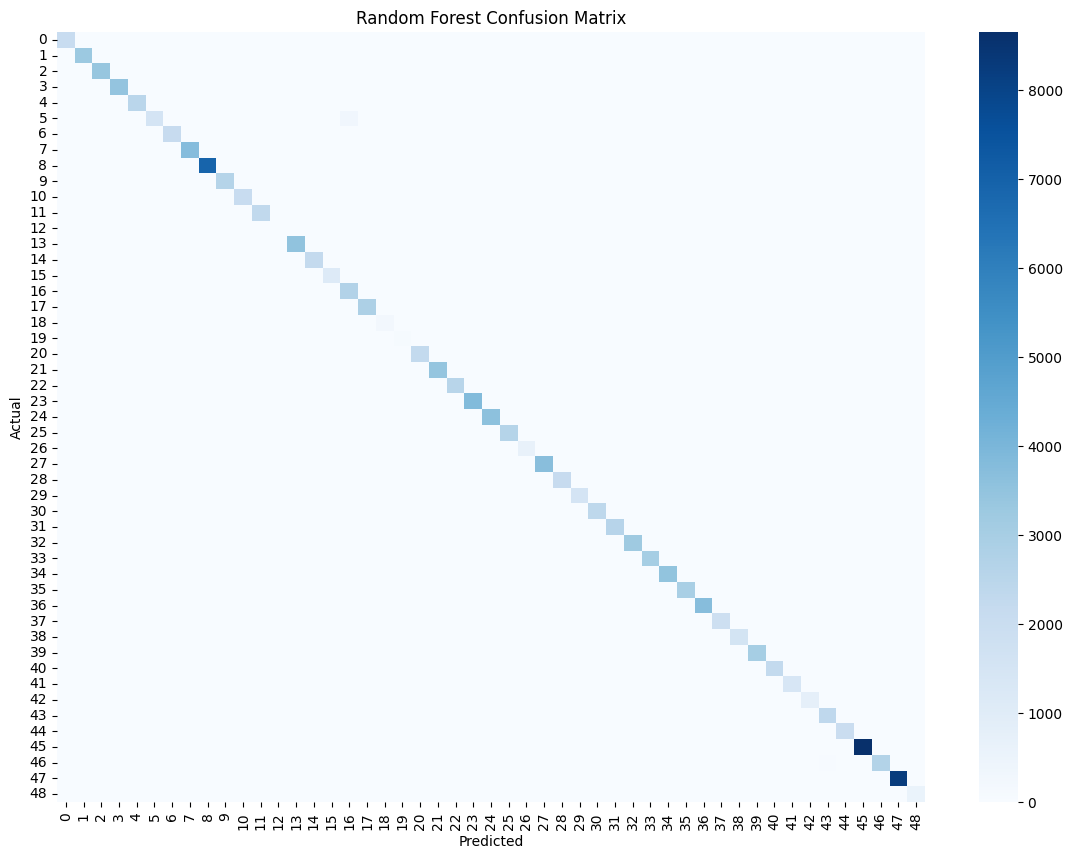

In [ ]:

# CONFUSION MATRIX


cm = confusion_matrix(
    y_valid_encoded,
    rf_pred
)

plt.figure(figsize=(14, 10))

sns.heatmap(
    cm,
    cmap="Blues"
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.savefig("random_forest_confusion_matrix.png")

plt.show()

In [ ]:

# SAVE MODEL AND ENCODERS


joblib.dump(
    rf_model,
    "random_forest_model.pkl"
)

joblib.dump(
    mlb,
    "rf_mlb_encoder.pkl"
)

joblib.dump(
    label_encoder,
    "rf_label_encoder.pkl"
)

print("Random Forest files saved successfully.")


Random Forest files saved successfully.


In [ ]:

# DOWNLOAD FILES


from google.colab import files

files.download("random_forest_model.pkl")

files.download("random_forest_confusion_matrix.png")

files.download("rf_mlb_encoder.pkl")

files.download("rf_label_encoder.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>